In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import random

# =====================================================
# SpecAugment
# =====================================================

class SpecAugment(nn.Module):
    def __init__(self, freq_mask_param=4, time_mask_param=8):
        super().__init__()
        self.freq_mask_param = freq_mask_param
        self.time_mask_param = time_mask_param

    def forward(self, x):

        # x shape: [B,1,F,T]

        if not self.training:
            return x

        x = x.clone()

        B, C, F, T = x.shape

        for i in range(B):

            # Frequency mask
            f = random.randint(0, self.freq_mask_param)
            f0 = random.randint(0, max(0, F - f))
            x[i, :, f0:f0+f, :] = 0

            # Time mask
            t = random.randint(0, self.time_mask_param)
            t0 = random.randint(0, max(0, T - t))
            x[i, :, :, t0:t0+t] = 0

        return x

# =====================================================
# Improved Teacher CNN
# =====================================================

class KWSCNNTeacherI(nn.Module):
    def __init__(self, num_classes=12):
        super().__init__()

        self.specaug = SpecAugment()

        self.features = nn.Sequential(

            # ---------------- Block 1 ----------------
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),

            nn.Conv2d(16, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),

            nn.MaxPool2d(2),
            nn.Dropout(0.10),

            # ---------------- Block 2 ----------------
            nn.Conv2d(16, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(2),
            nn.Dropout(0.15),

            # ---------------- Block 3 ----------------
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Dropout(0.20),

            # ---------------- Block 4 ----------------
            nn.Conv2d(128, 192, kernel_size=3, padding=1),
            nn.BatchNorm2d(192),
            nn.ReLU()
        )

        self.pool = nn.AdaptiveAvgPool2d((1,1))

        self.classifier = nn.Sequential(
            nn.Linear(192, 128),
            nn.ReLU(),
            nn.Dropout(0.35),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):

        x = self.specaug(x)

        x = self.features(x)
        x = self.pool(x)
        x = x.flatten(1)

        return self.classifier(x)

# =====================================================
# Load data
# =====================================================

data = torch.load("/content/drive/MyDrive/gsc_mfcc_40x98.pt")

X_train = data["X_train"].unsqueeze(1).float()
y_train = data["y_train"]

X_val = data["X_val"].unsqueeze(1).float()
y_val = data["y_val"]

# =====================================================
# Normalize
# =====================================================

mean = X_train.mean()
std = X_train.std()

X_train = (X_train - mean) / std
X_val = (X_val - mean) / std

# =====================================================
# Dataset
# =====================================================

train_ds = torch.utils.data.TensorDataset(X_train, y_train)
val_ds = torch.utils.data.TensorDataset(X_val, y_val)

train_loader = torch.utils.data.DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = torch.utils.data.DataLoader(
    val_ds,
    batch_size=32,
    num_workers=2,
    pin_memory=True
)

# =====================================================
# Device
# =====================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =====================================================
# Model
# =====================================================

model = KWSCNNTeacherI(num_classes=12).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=3e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=2,
)

# =====================================================
# Arrays
# =====================================================

train_losses = []
val_losses = []
train_accs = []
val_accs = []

# =====================================================
# Early stopping
# =====================================================

epochs = 30
best_val_acc = 0
patience = 6
counter = 0

# =====================================================
# Training loop
# =====================================================

for epoch in range(epochs):

    # ---------------- TRAIN ----------------
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")

    for x, y in pbar:

        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(x)
        loss = criterion(outputs, y)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        preds = outputs.argmax(1)
        correct += (preds == y).sum().item()
        total += y.size(0)

        pbar.set_postfix(
            loss=running_loss / (total / y.size(0)),
            acc=correct / total
        )

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # ---------------- VALIDATION ----------------
    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]")

        for x, y in pbar:

            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            outputs = model(x)
            loss = criterion(outputs, y)

            running_loss += loss.item()

            preds = outputs.argmax(1)
            correct += (preds == y).sum().item()
            total += y.size(0)

            pbar.set_postfix(
                loss=running_loss / (total / y.size(0)),
                acc=correct / total
            )

    val_loss = running_loss / len(val_loader)
    val_acc = correct / total

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")

    scheduler.step(val_acc)

    # ---------------- Save best ----------------
    if val_acc > best_val_acc:

        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_teacher.pth")
        print(" Best model saved")
        counter = 0

    else:
        counter += 1
        print(f" No improvement ({counter}/{patience})")

        if counter >= patience:
            print(" Early stopping triggered")
            break

print(f"\n Best Validation Accuracy: {best_val_acc:.4f}")

Epoch 1/30 [Val]: 100%|██████████| 165/165 [00:01<00:00, 143.22it/s, acc=0.853, loss=0.0602]



Epoch 1
Train Loss: 1.4990 | Train Acc: 0.5855
Val Loss:   0.9584 | Val Acc:   0.8531
✅ Best model saved


Epoch 2/30 [Val]: 100%|██████████| 165/165 [00:01<00:00, 147.52it/s, acc=0.877, loss=0.0566]



Epoch 2
Train Loss: 1.0014 | Train Acc: 0.8367
Val Loss:   0.9002 | Val Acc:   0.8768
✅ Best model saved


Epoch 3/30 [Val]: 100%|██████████| 165/165 [00:01<00:00, 106.64it/s, acc=0.916, loss=0.049]


...


Epoch 28
Train Loss: 0.6486 | Train Acc: 0.9661
Val Loss:   0.6331 | Val Acc:   0.9608
⚠️ No improvement (3/6)


Epoch 29/30 [Val]: 100%|██████████| 165/165 [00:01<00:00, 107.60it/s, acc=0.96, loss=0.0397]



Epoch 29
Train Loss: 0.6377 | Train Acc: 0.9698
Val Loss:   0.6313 | Val Acc:   0.9596
⚠️ No improvement (4/6)


Epoch 30/30 [Val]: 100%|██████████| 165/165 [00:01<00:00, 130.68it/s, acc=0.962, loss=0.0394]


Epoch 30
Train Loss: 0.6392 | Train Acc: 0.9701
Val Loss:   0.6263 | Val Acc:   0.9619
⚠️ No improvement (5/6)

✅ Best Validation Accuracy: 0.9632



--- Evaluating Retrained Teacher Model ---


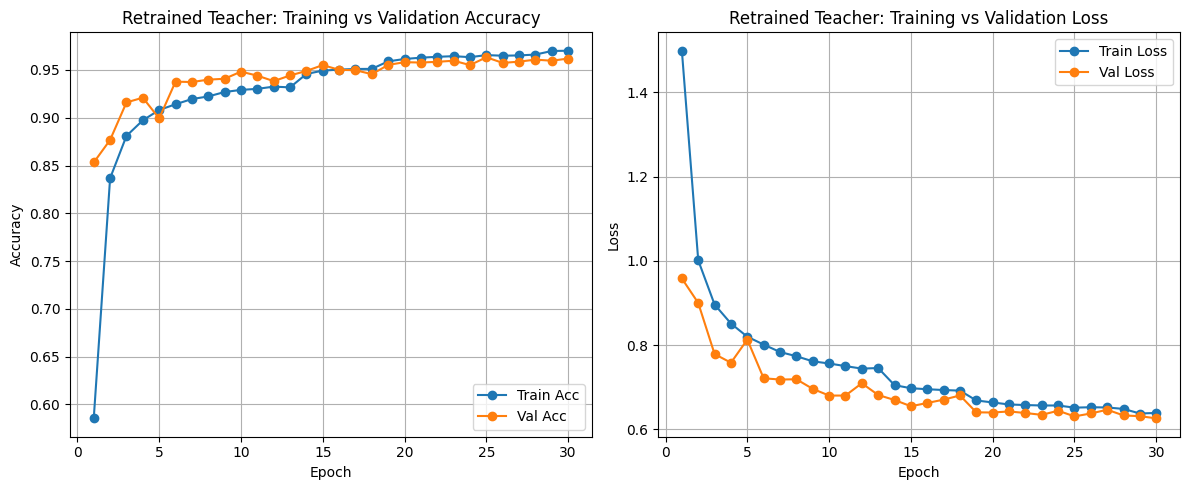

In [ ]:
import matplotlib.pyplot as plt


print("\n--- Evaluating Retrained Teacher Model ---")

# Load the best retrained model
best_teacher_retrained = KWSCNNTeacherI(num_classes=12).to(device)
best_teacher_retrained.load_state_dict(torch.load("/content/best_teacher.pth", map_location=device))
best_teacher_retrained.eval()

# Evaluate on the test set
# test_loss_retrained, test_acc_retrained = evaluate(best_teacher_retrained, test_loader, criterion_retrained, device, epoch=0)

# print(f"\nRetrained Teacher Model Test Loss: {test_loss_retrained:.4f}")
# print(f"Retrained Teacher Model Test Accuracy: {test_acc_retrained:.4f}")

# Plotting training and validation metrics
epochs = range(1, len(train_accs) + 1)

plt.figure(figsize=(12, 5))

# --- Accuracy ---
plt.subplot(1, 2, 1)
plt.plot(epochs, train_accs, label='Train Acc', marker='o')
plt.plot(epochs, val_accs, label='Val Acc', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Retrained Teacher: Training vs Validation Accuracy')
plt.legend()
plt.grid(True)

# --- Loss ---
plt.subplot(1, 2, 2)
plt.plot(epochs, train_losses, label='Train Loss', marker='o')
plt.plot(epochs, val_losses, label='Val Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Retrained Teacher: Training vs Validation Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# =====================================================
# Load test data
# =====================================================

data = torch.load("/content/drive/MyDrive/gsc_mfcc_40x98.pt")  # same dataset file

X_test = data["X_test"].unsqueeze(1).float()
y_test = data["y_test"]

# Normalize using training mean/std
mean = data["X_train"].mean()
std = data["X_train"].std()

X_test = (X_test - mean) / std

# Create DataLoader
test_ds = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

# =====================================================
# Load model
# =====================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = KWSCNNTeacherI(num_classes=12).to(device)

# Load best saved weights
model.load_state_dict(torch.load("best_teacher.pth", map_location=device))
model.eval()

# =====================================================
# Evaluate test accuracy
# =====================================================

correct = 0
total = 0

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        y = y.to(device)

        outputs = model(x)
        preds = outputs.argmax(1)

        correct += (preds == y).sum().item()
        total += y.size(0)

test_acc = correct / total
print(f"✅ Test Accuracy: {test_acc:.4f}")

✅ Test Accuracy: 0.9691
